# **Nits Tropicals / Tòrrides i Duració d'Estius / Hiverns**

Aquest notebook analitza dos fenòmens:

---
### Part 1 — Nits Tropicals, Tòrrides i Fresques
**Estació**: Sabadell Centre (Sbd_Centre_daily.csv)

**Classificació** de cada dia segons T_min:
- **Fresca** (Cool): T_min ≤ 20°C
- **Tropical**: 20°C < T_min ≤ 25°C
- **Tòrrida** (Torrid): 25°C < T_min ≤ 30°C
- **Infernal**: T_min > 30°C

---
### Part 2 — Duració d'Estius (expansió)
**Estacions**: Vacarisses (1996–) i Sabadell Nord (2009–)

**Mètode**: partint del *core* estival (21 juny → 21 setembre), expandim simètricament la finestra fins que T_avg mitjana iguali la del core de referència (primers 5 anys complets). L'increment de dies = allargament de l'estiu.

---
### Part 3 — Duració d'Hiverns (contracció)
**Estacions**: Vacarisses, Sabadell Nord i Sabadell Centre

**Mètode**: mateixa lògica que l'estiu, amb el core hivernal (21 des → 21 març) creuant any.

## 1. Càrrega i Preparació de Dades

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

URL_BASE = 'https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/'

df_centre = pd.read_csv(URL_BASE + 'Sbd_Centre_daily.csv')
df_centre['date'] = pd.to_datetime(df_centre['date'])
df_centre['year'] = df_centre['date'].dt.year
df_centre['month'] = df_centre['date'].dt.month
df_centre['day'] = df_centre['date'].dt.day

df_vaca = pd.read_csv(URL_BASE + 'Vacarisses_daily.csv')
df_vaca['date'] = pd.to_datetime(df_vaca['date'])
df_vaca['year'] = df_vaca['date'].dt.year
df_vaca['month'] = df_vaca['date'].dt.month
df_vaca['day'] = df_vaca['date'].dt.day

df_nord = pd.read_csv(URL_BASE + 'Sbd_nord_daily.csv')
df_nord['date'] = pd.to_datetime(df_nord['date'])
df_nord['year'] = df_nord['date'].dt.year
df_nord['month'] = df_nord['date'].dt.month
df_nord['day'] = df_nord['date'].dt.day

print('Dades carregades.')
print(f'  Sabadell Centre: {df_centre["date"].min().date()} → {df_centre["date"].max().date()} ({len(df_centre)} dies)')
print(f'  Vacarisses:      {df_vaca["date"].min().date()} → {df_vaca["date"].max().date()} ({len(df_vaca)} dies)')
print(f'  Sabadell Nord:   {df_nord["date"].min().date()} → {df_nord["date"].max().date()} ({len(df_nord)} dies)')

Dades carregades.
  Sabadell Centre: 2008-05-06 → 2026-01-31 (5834 dies)
  Vacarisses:      1996-02-16 → 2026-04-01 (10960 dies)
  Sabadell Nord:   2008-10-24 → 2026-04-01 (6369 dies)


---
## Part 1 — Nits Tropicals, Tòrrides i Fresques (Sabadell Centre)

### 2.1 Classificació de nits

In [58]:
def classify_night(t_min):
    if pd.isna(t_min):
        return None
    if t_min > 30:
        return 'Infernal (>30°C)'
    elif t_min > 25:
        return 'Tòrrida (>25°C)'
    elif t_min > 20:
        return 'Tropical (>20°C)'
    else:
        return 'Fresca (≤20°C)'

df_centre['night_type'] = df_centre['T_min'].apply(classify_night)

print('Classificació global (tots els anys):')
print(df_centre['night_type'].value_counts().to_string())
print()
print(f'Total dies amb T_min vàlida: {df_centre["night_type"].notna().sum()}')

Classificació global (tots els anys):
night_type
Fresca (≤20°C)      4912
Tropical (>20°C)     897
Tòrrida (>25°C)       24
Infernal (>30°C)       1

Total dies amb T_min vàlida: 5834


### 2.2 Evolució anual

In [59]:
yearly_counts = (
    df_centre[df_centre['night_type'].notna()]
    .groupby(['year', 'night_type'])
    .size()
    .unstack(fill_value=0)
)
yearly_counts['total'] = yearly_counts.sum(axis=1)

valid_years = yearly_counts[yearly_counts['total'] >= 200].index
yearly_filt = yearly_counts.loc[valid_years]

print(f'Anys vàlids: {sorted(valid_years.tolist())}')

cats_ordered = ['Fresca (≤20°C)', 'Tropical (>20°C)', 'Tòrrida (>25°C)', 'Infernal (>30°C)']
available_cats = [c for c in cats_ordered if c in yearly_filt.columns]
yearly_pct = yearly_filt[available_cats].div(yearly_filt['total'], axis=0) * 100

Anys vàlids: [2009, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


### 2.3 Visualització — Stacked Bar + Sub-pie Charts

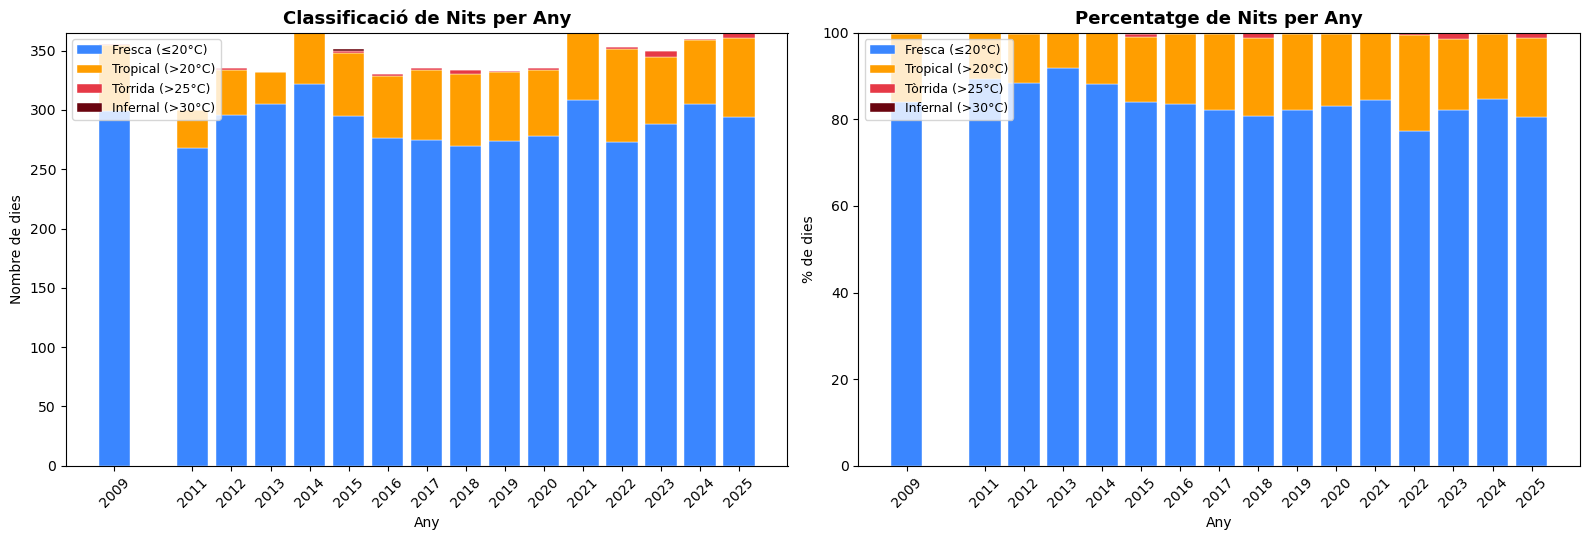

In [60]:
colors_types = {
    'Fresca (≤20°C)': '#3a86ff',
    'Tropical (>20°C)': '#ff9e00',
    'Tòrrida (>25°C)': '#e63946',
    'Infernal (>30°C)': '#6a040f',
}
plot_cats = [c for c in cats_ordered if c in yearly_filt.columns]
plot_colors = [colors_types[c] for c in plot_cats]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

bottom = np.zeros(len(yearly_filt))
for cat, color in zip(plot_cats, plot_colors):
    vals = yearly_filt[cat].values if cat in yearly_filt.columns else np.zeros(len(yearly_filt))
    ax1.bar(yearly_filt.index, vals, bottom=bottom, color=color, edgecolor='white', linewidth=0.3, label=cat)
    bottom += vals
ax1.set_title('Classificació de Nits per Any', fontsize=13, fontweight='bold')
ax1.set_xlabel('Any'); ax1.set_ylabel('Nombre de dies')
ax1.legend(fontsize=9, loc='upper left')
ax1.set_xticks(yearly_filt.index)
ax1.tick_params(axis='x', rotation=45)

bottom = np.zeros(len(yearly_pct))
for cat, color in zip(plot_cats, plot_colors):
    vals = yearly_pct[cat].values if cat in yearly_pct.columns else np.zeros(len(yearly_pct))
    ax2.bar(yearly_pct.index, vals, bottom=bottom, color=color, edgecolor='white', linewidth=0.3, label=cat)
    bottom += vals
ax2.set_title('Percentatge de Nits per Any', fontsize=13, fontweight='bold')
ax2.set_xlabel('Any'); ax2.set_ylabel('% de dies')
ax2.legend(fontsize=9, loc='upper left')
ax2.set_xticks(yearly_pct.index)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

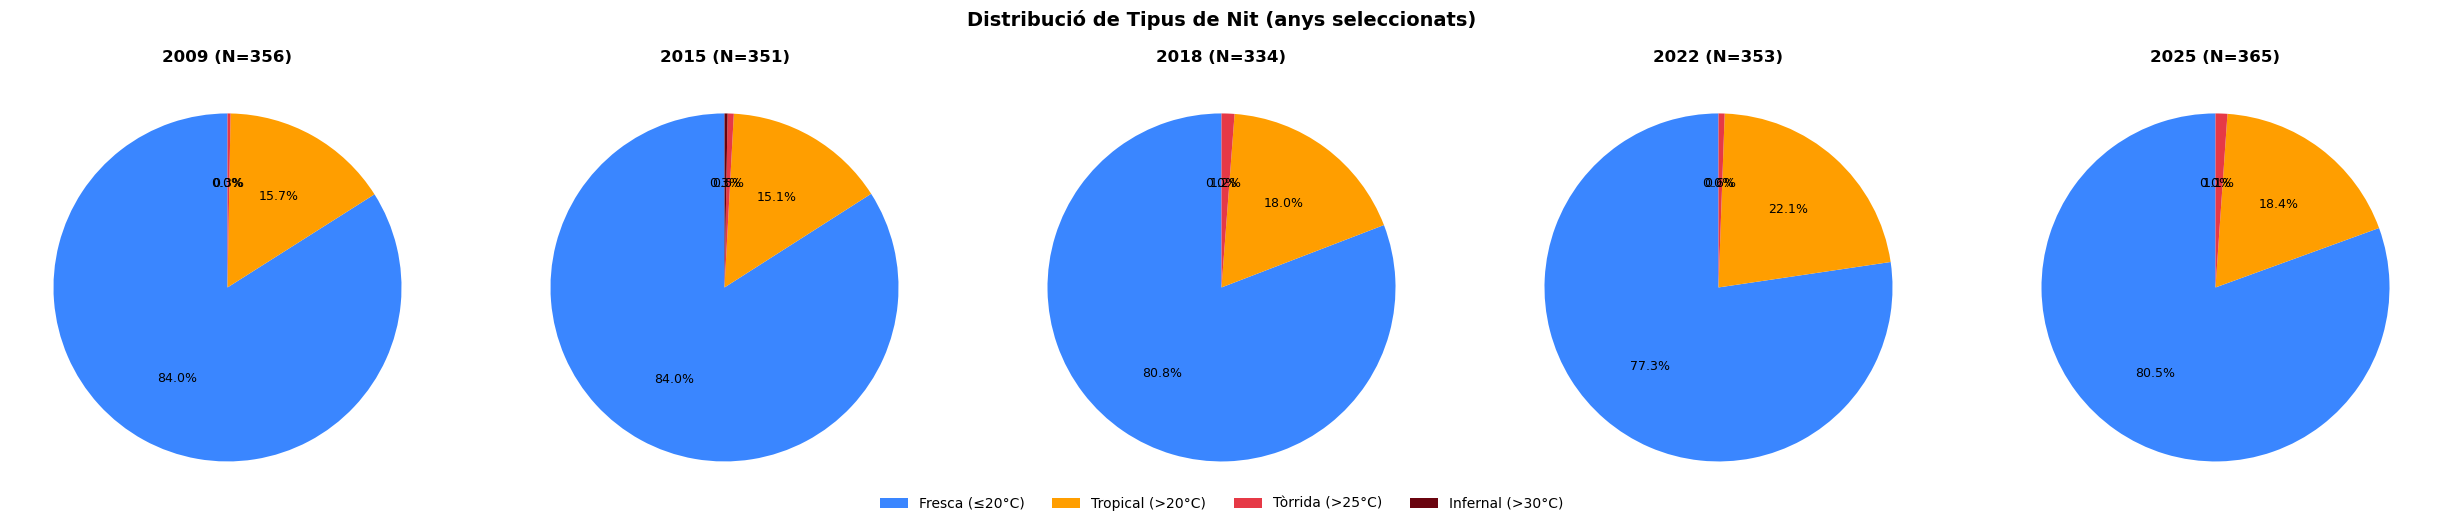

In [61]:
all_valid_years = sorted(yearly_filt.index.tolist())
pie_years = [all_valid_years[0], 2015, 2018, all_valid_years[-1]]
if 2022 not in pie_years:
    pie_years.append(2022)
pie_years = sorted(pie_years)

fig, axes = plt.subplots(1, len(pie_years), figsize=(5 * len(pie_years), 5))
if len(pie_years) == 1:
    axes = [axes]

for ax, year in zip(axes, pie_years):
    data = yearly_filt.loc[year, plot_cats].values
    total = yearly_filt.loc[year, 'total']
    wedges, _, autotexts = ax.pie(
        data, labels=None, autopct='%1.1f%%',
        colors=plot_colors, startangle=90,
        textprops={'fontsize': 9}
    )
    ax.set_title(f'{year} (N={total})', fontsize=12, fontweight='bold')

fig.legend(wedges, plot_cats, loc='lower center', ncol=len(plot_cats),
           fontsize=10, frameon=False)
plt.suptitle('Distribució de Tipus de Nit (anys seleccionats)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.4 Tendència de % de nits càlides

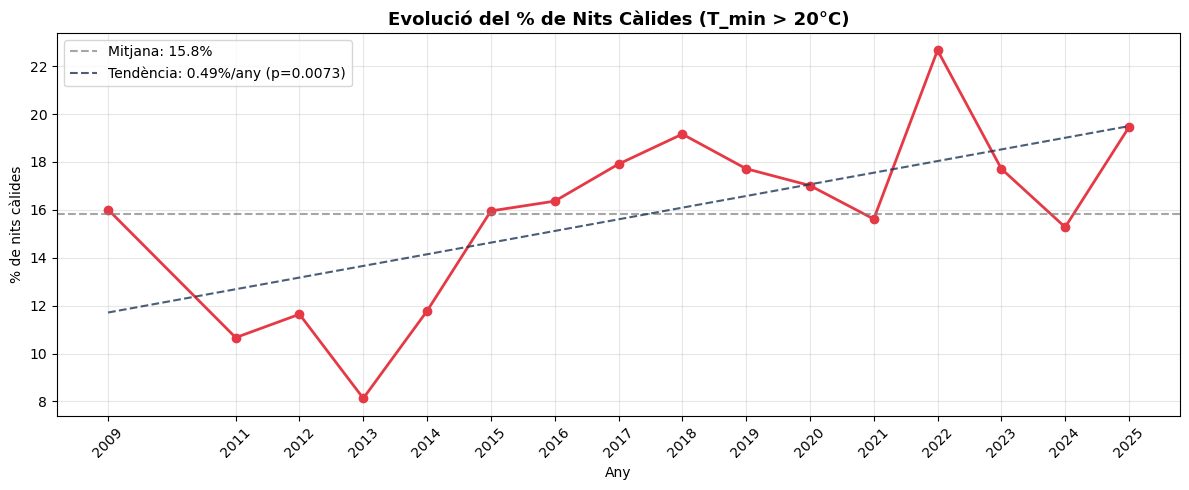

In [62]:
warm_cats = [c for c in ['Tropical (>20°C)', 'Tòrrida (>25°C)', 'Infernal (>30°C)'] if c in yearly_filt.columns]
yearly_filt['warm_pct'] = yearly_filt[warm_cats].sum(axis=1) / yearly_filt['total'] * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly_filt.index, yearly_filt['warm_pct'], 'o-', color='#e63946', linewidth=2, markersize=6)
ax.axhline(yearly_filt['warm_pct'].mean(), color='gray', linestyle='--', alpha=0.7,
           label=f'Mitjana: {yearly_filt["warm_pct"].mean():.1f}%')

slope, intercept, r_val, p_val, _ = stats.linregress(yearly_filt.index, yearly_filt['warm_pct'])
x_line = np.array([yearly_filt.index.min(), yearly_filt.index.max()])
ax.plot(x_line, intercept + slope * x_line, '--', color='#1d3557', alpha=0.8,
        label=f'Tendència: {slope:.2f}%/any (p={p_val:.4f})')

ax.set_title('Evolució del % de Nits Càlides (T_min > 20°C)', fontsize=13, fontweight='bold')
ax.set_xlabel('Any'); ax.set_ylabel('% de nits càlides')
ax.legend(fontsize=10)
ax.set_xticks(yearly_filt.index)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
import sys, os
scripts_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'scripts'))
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)
from statistical_tests import mk_analysis_series, print_mk_table

print('\n' + '='*60)
print('ESTUDI ESTADÍSTIC — % NITS CÀLIDES')
print('='*60)
years = yearly_filt.index.values
vals = yearly_filt['warm_pct'].values
r = mk_analysis_series(years, vals, '% Nits càlides (>20°C) — Sbd Centre')
print(r['summary'])



ESTUDI ESTADÍSTIC — % NITS CÀLIDES
--- % Nits càlides (>20°C) — Sbd Centre ---
  Mann-Kendall tau = 0.4333, p = 0.0198 (increasing)
  Sen's slope = 0.4694 per year [0.1004, 0.9584]
  Pettitt change point: index=6, year~2016, p=0.5772 (not significant)
  Significant at: alpha=0.05 YES, alpha=0.01 no


---
## Part 2 — Duració d'Estius

**Estacions**: Vacarisses (ref: 1996–2000) i Sabadell Nord (ref: 2009–2013)

**Mètode**: Des del core (21 juny → 21 setembre), expandim simètricament fins que T_avg < T_ref.

### 3.1 Funció d'expansió general (estiu + hivern)

In [64]:
def expand_season(df, year, mode='summer', target_tavg=None, min_core_days=10):
    """
    Expandeix simètricament la finestra al voltant del core.

    mode='summer':
      core = 21 Jun → 21 Set (mateix any)
      stop when T_avg < target_tavg
    mode='winter':
      core = 21 Des → 21 Mar (any→any+1)
      stop when T_avg > target_tavg

    Retorna {year, duration_days, core_days, window_tavg} o None.
    """
    if mode == 'summer':
        core_start = pd.Timestamp(f'{year}-06-21')
        core_end = pd.Timestamp(f'{year}-09-21')
        # Finestra de dades: 1 maig → 31 oct
        data_start = pd.Timestamp(f'{year}-05-01')
        data_end = pd.Timestamp(f'{year}-10-31')
    else:  # winter
        core_start = pd.Timestamp(f'{year}-12-21')
        core_end = pd.Timestamp(f'{year+1}-03-21')
        # Finestra de dades: 1 nov → 30 abr següent
        data_start = pd.Timestamp(f'{year}-11-01')
        data_end = pd.Timestamp(f'{year+1}-04-30')

    season_data = df[(df['date'] >= data_start) & (df['date'] <= data_end)]\
        .sort_values('date').reset_index(drop=True).copy()

    if len(season_data) < 30:
        return None

    core_mask = (season_data['date'] >= core_start) & (season_data['date'] <= core_end)
    if core_mask.sum() < min_core_days:
        return None

    core_idx = np.where(core_mask)[0]
    left_pos, right_pos = int(core_idx[0]), int(core_idx[-1])

    core_tavg = season_data.loc[core_idx, 'T_avg'].dropna()
    if len(core_tavg) < min_core_days:
        return None
    core_days_count = len(core_tavg)

    if target_tavg is None:
        target_tavg = core_tavg.mean()

    while left_pos > 0 and right_pos < len(season_data) - 1:
        window = season_data.iloc[left_pos-1:right_pos+2]['T_avg'].dropna()
        tavg = window.mean()
        if mode == 'summer' and tavg < target_tavg:
            break
        if mode == 'winter' and tavg > target_tavg:
            break
        left_pos -= 1
        right_pos += 1

    window_final = season_data.iloc[left_pos:right_pos+1]['T_avg'].dropna()

    return {
        'year': year,
        'duration_days': len(window_final),
        'core_days': core_days_count,
        'window_tavg': window_final.mean(),
        'target_tavg': target_tavg,
    }


def compute_ref_tavg(df, years, mode='summer'):
    """T_avg mitjana del core per un conjunt d'anys de referència."""
    all_core = []
    for y in years:
        if mode == 'summer':
            core_start, core_end = f'{y}-06-21', f'{y}-09-21'
        else:
            core_start, core_end = f'{y}-12-21', f'{y+1}-03-21'
        mask = (df['date'] >= core_start) & (df['date'] <= core_end)
        all_core.append(df[mask]['T_avg'])
    return pd.concat(all_core).dropna().mean()


SUMMER_CORE_DAYS = 93  # 21 jun → 21 set
WINTER_CORE_DAYS = 91  # ~21 des → 21 mar

REF_YEARS_VACA = [1996, 1997, 1998, 1999, 2000]
REF_YEARS_NORD = [2009, 2010, 2011, 2012, 2013]
LAST_YEARS = [2021, 2022, 2023, 2024, 2025]

print('Funcions a punt.')

Funcions a punt.


### 3.2 Vacarisses — Estiu

In [65]:
vaca_ref_tavg = compute_ref_tavg(df_vaca, REF_YEARS_VACA, mode='summer')
print(f'T_ref (Vacarisses, estiu {REF_YEARS_VACA[0]}-{REF_YEARS_VACA[-1]}): {vaca_ref_tavg:.2f}°C')

vaca_summer = []
for y in LAST_YEARS:
    res = expand_season(df_vaca, y, mode='summer', target_tavg=vaca_ref_tavg)
    if res:
        vaca_summer.append(res)
        print(f'  {y}: {res["duration_days"]} dies (T_finestra: {res["window_tavg"]:.2f}°C)')
df_vaca_s = pd.DataFrame(vaca_summer)
df_vaca_s['expansion'] = df_vaca_s['duration_days'] - SUMMER_CORE_DAYS
print(f'\nExpansió mitjana: {df_vaca_s["expansion"].mean():.0f} dies')

T_ref (Vacarisses, estiu 1996-2000): 21.72°C
  2021: 117 dies (T_finestra: 21.80°C)
  2022: 165 dies (T_finestra: 21.76°C)
  2023: 151 dies (T_finestra: 21.79°C)
  2024: 113 dies (T_finestra: 21.76°C)
  2025: 149 dies (T_finestra: 21.74°C)

Expansió mitjana: 46 dies


### 3.3 Sabadell Nord — Estiu

In [66]:
nord_ref_tavg = compute_ref_tavg(df_nord, REF_YEARS_NORD, mode='summer')
print(f'T_ref (Sbd Nord, estiu {REF_YEARS_NORD[0]}-{REF_YEARS_NORD[-1]}): {nord_ref_tavg:.2f}°C')

nord_summer = []
for y in LAST_YEARS:
    res = expand_season(df_nord, y, mode='summer', target_tavg=nord_ref_tavg)
    if res:
        nord_summer.append(res)
        print(f'  {y}: {res["duration_days"]} dies (T_finestra: {res["window_tavg"]:.2f}°C)')
df_nord_s = pd.DataFrame(nord_summer)
df_nord_s['expansion'] = df_nord_s['duration_days'] - SUMMER_CORE_DAYS
print(f'\nExpansió mitjana: {df_nord_s["expansion"].mean():.0f} dies')

T_ref (Sbd Nord, estiu 2009-2013): 22.73°C
  2021: 117 dies (T_finestra: 22.81°C)
  2022: 167 dies (T_finestra: 22.78°C)
  2023: 153 dies (T_finestra: 22.76°C)
  2024: 111 dies (T_finestra: 22.78°C)
  2025: 149 dies (T_finestra: 22.74°C)

Expansió mitjana: 46 dies


### 3.4 Visualització — Comparació d'Estius

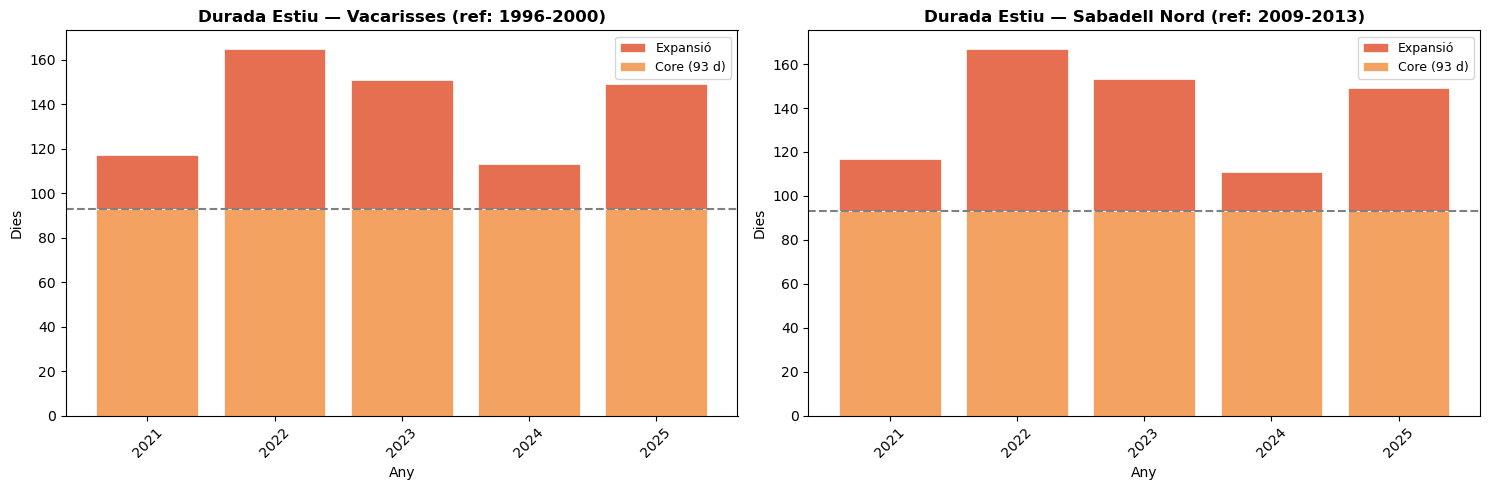

Vacarisses: durada mitjana = 139 dies (+46 respecto al core)
Sbd Nord: durada mitjana = 139 dies (+46 respecto al core)


In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for ax, df_res, name, ref_label in [
    (ax1, df_vaca_s, 'Vacarisses', f'{REF_YEARS_VACA[0]}-{REF_YEARS_VACA[-1]}'),
    (ax2, df_nord_s, 'Sabadell Nord', f'{REF_YEARS_NORD[0]}-{REF_YEARS_NORD[-1]}'),
]:
    ax.bar(df_res['year'], df_res['expansion'], bottom=SUMMER_CORE_DAYS,
           color='#e76f51', edgecolor='white', linewidth=0.5, label='Expansió')
    ax.bar(df_res['year'], [SUMMER_CORE_DAYS] * len(df_res),
           color='#f4a261', edgecolor='white', linewidth=0.5, label=f'Core ({SUMMER_CORE_DAYS} d)')
    ax.axhline(SUMMER_CORE_DAYS, color='gray', linestyle='--')
    ax.set_title(f'Durada Estiu — {name} (ref: {ref_label})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Any'); ax.set_ylabel('Dies')
    ax.legend(fontsize=9)
    ax.set_xticks(df_res['year'])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('='*50)
for df_res, name in [(df_vaca_s, 'Vacarisses'), (df_nord_s, 'Sbd Nord')]:
    print(f'{name}: durada mitjana = {df_res["duration_days"].mean():.0f} dies '
          f'(+{df_res["expansion"].mean():.0f} respecto al core)')

In [68]:
import sys, os
scripts_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'scripts'))
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)
from statistical_tests import mk_analysis_series, print_mk_table

def _valid_summer_years(df, start, end):
    valid = []
    for y in range(start, end + 1):
        ds = pd.Timestamp(f'{y}-05-01')
        de = pd.Timestamp(f'{y}-10-31')
        season = df[(df['date'] >= ds) & (df['date'] <= de)]
        if len(season) >= 30:
            valid.append(y)
    return valid

def _duration_series(df, years, mode, ref_tavg):
    res = []
    for y in years:
        r = expand_season(df, y, mode=mode, target_tavg=ref_tavg)
        if r:
            res.append({'year': y, 'duration_days': r['duration_days']})
    return pd.DataFrame(res)

print('\n' + '='*60)
print('ESTUDI ESTADÍSTIC — DURACIÓ ESTIUS (TOTS ELS ANYS)')
print('='*60)

mk_res = []
for name, df, ref_tavg, sy in [
    ('Vacarisses', df_vaca, vaca_ref_tavg, 1996),
    ('Sabadell Nord', df_nord, nord_ref_tavg, 2009),
]:
    years = _valid_summer_years(df, sy, 2025)
    ddf = _duration_series(df, years, 'summer', ref_tavg)
    if len(ddf) >= 5:
        r = mk_analysis_series(ddf['year'].values, ddf['duration_days'].values,
                               f'Durada estiu — {name}')
        mk_res.append(r)
        print(r['summary'])
    else:
        print(name + ': insuficients anys (' + str(len(ddf)) + ')')

if mk_res:
    print('\n' + '-'*60)
    print_mk_table(mk_res)



ESTUDI ESTADÍSTIC — DURACIÓ ESTIUS (TOTS ELS ANYS)
--- Durada estiu — Vacarisses ---
  Mann-Kendall tau = 0.2942, p = 0.0251 (increasing)
  Sen's slope = 0.8571 per year [0.0000, 1.7600]
  Pettitt change point: index=19, year~2015, p=0.5311 (not significant)
  Significant at: alpha=0.05 YES, alpha=0.01 no
--- Durada estiu — Sabadell Nord ---
  Mann-Kendall tau = 0.5760, p = 0.0016 (increasing)
  Sen's slope = 3.2000 per year [1.3333, 4.6667]
  Pettitt change point: index=7, year~2016, p=0.3941 (not significant)
  Significant at: alpha=0.05 YES, alpha=0.01 YES

------------------------------------------------------------
Label                                              tau   MK p-value      Slope Trend           Sig 0.05  CP year
----------------------------------------------------------------------------------------------------------------
Durada estiu — Vacarisses                       0.2942     0.0251     0.8571 increasing             Y     2015
Durada estiu — Sabadell Nord      

---
## Part 3 — Duració d'Hiverns

**Estacions**: Vacarisses (ref: 1996–2000), Sabadell Nord i Centre (ref: 2009–2013)

**Mètode**: Des del core (21 des → 21 març), expandim simètricament fins que T_avg > T_ref.
L'hivern creua any: 'any' 2021 significa 21 des 2021 → 21 mar 2022.

### 4.1 Càlcul de referències i expansió — Totes les estacions

In [69]:
vaca_w_ref = compute_ref_tavg(df_vaca, REF_YEARS_VACA, mode='winter')
nord_w_ref = compute_ref_tavg(df_nord, REF_YEARS_NORD, mode='winter')
centre_w_ref = compute_ref_tavg(df_centre, REF_YEARS_NORD, mode='winter')

print('T_ref hivern:')
print(f'  Vacarisses ({REF_YEARS_VACA[0]}-{REF_YEARS_VACA[-1]}): {vaca_w_ref:.2f}°C')
print(f'  Sbd Nord ({REF_YEARS_NORD[0]}-{REF_YEARS_NORD[-1]}): {nord_w_ref:.2f}°C')
print(f'  Sbd Centre ({REF_YEARS_NORD[0]}-{REF_YEARS_NORD[-1]}): {centre_w_ref:.2f}°C')
print()

winter_tasks = [
    ('Vacarisses', df_vaca, vaca_w_ref),
    ('Sabadell Nord', df_nord, nord_w_ref),
    ('Sabadell Centre', df_centre, centre_w_ref),
]

all_winter = {}

for name, df, ref_tavg in winter_tasks:
    results = []
    print(f'--- {name} ---')
    for y in LAST_YEARS:
        res = expand_season(df, y, mode='winter', target_tavg=ref_tavg)
        if res:
            results.append(res)
            print(f'  Hivern {y}: {res["duration_days"]} dies '
                  f'(T_finestra: {res["window_tavg"]:.2f}°C)')
    all_winter[name] = pd.DataFrame(results)
    print()

T_ref hivern:
  Vacarisses (1996-2000): 7.24°C
  Sbd Nord (2009-2013): 7.55°C
  Sbd Centre (2009-2013): 9.62°C

--- Vacarisses ---
  Hivern 2021: 153 dies (T_finestra: 7.24°C)
  Hivern 2022: 111 dies (T_finestra: 7.19°C)
  Hivern 2023: 92 dies (T_finestra: 8.13°C)
  Hivern 2024: 117 dies (T_finestra: 7.23°C)
  Hivern 2025: 91 dies (T_finestra: 7.58°C)

--- Sabadell Nord ---
  Hivern 2021: 91 dies (T_finestra: 8.79°C)
  Hivern 2022: 91 dies (T_finestra: 8.89°C)
  Hivern 2023: 92 dies (T_finestra: 10.19°C)
  Hivern 2024: 91 dies (T_finestra: 8.90°C)
  Hivern 2025: 91 dies (T_finestra: 9.16°C)

--- Sabadell Centre ---
  Hivern 2021: 91 dies (T_finestra: 10.49°C)
  Hivern 2022: 78 dies (T_finestra: 9.81°C)
  Hivern 2023: 92 dies (T_finestra: 11.73°C)
  Hivern 2024: 91 dies (T_finestra: 10.49°C)
  Hivern 2025: 42 dies (T_finestra: 9.01°C)



### 4.2 Visualització — Comparació d'Hiverns

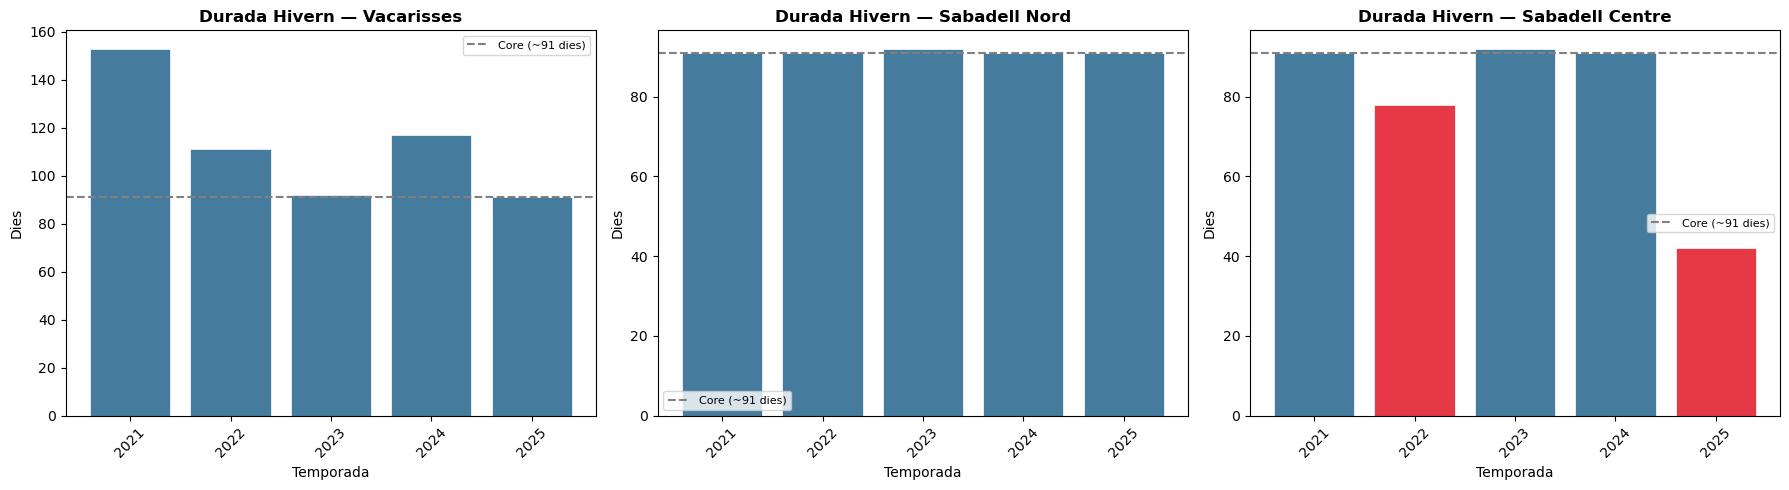

Vacarisses: durada mitjana = 113 dies (MÉS LLARG: 22 dies vs core)
Sabadell Nord: durada mitjana = 91 dies (MÉS LLARG: 0 dies vs core)
Sabadell Centre: durada mitjana = 79 dies (MÉS CURT: 12 dies vs core)


In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df_res) in zip(axes, all_winter.items()):
    if df_res.empty:
        ax.text(0.5, 0.5, 'Sense dades', ha='center', va='center', transform=ax.transAxes)
        continue
    df_res = df_res.sort_values('year')
    df_res['diff'] = df_res['duration_days'] - WINTER_CORE_DAYS
    colors_bar = ['#e63946' if d < 0 else '#457b9d' for d in df_res['diff']]

    ax.bar(df_res['year'], df_res['duration_days'],
           color=colors_bar, edgecolor='white', linewidth=0.5)
    ax.axhline(WINTER_CORE_DAYS, color='gray', linestyle='--',
               label=f'Core (~{WINTER_CORE_DAYS} dies)')
    ax.set_title(f'Durada Hivern — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Temporada'); ax.set_ylabel('Dies')
    ax.legend(fontsize=8)
    ax.set_xticks(df_res['year'])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('='*50)
for name, df_res in all_winter.items():
    if df_res.empty:
        continue
    df_res_sorted = df_res.sort_values('year')
    df_res_sorted['diff'] = df_res_sorted['duration_days'] - WINTER_CORE_DAYS
    mean_diff = df_res_sorted['diff'].mean()
    status = 'MÉS CURT' if mean_diff < 0 else 'MÉS LLARG'
    print(f'{name}: durada mitjana = {df_res_sorted["duration_days"].mean():.0f} dies '
          f'({status}: {abs(mean_diff):.0f} dies vs core)')

In [71]:
import sys, os
scripts_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'scripts'))
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)
from statistical_tests import mk_analysis_series, print_mk_table

def _duration_series(df, years, mode, ref_tavg):
    res = []
    for y in years:
        r = expand_season(df, y, mode=mode, target_tavg=ref_tavg)
        if r:
            res.append({'year': y, 'duration_days': r['duration_days']})
    return pd.DataFrame(res)

def _valid_winter_years(df, start, end):
    valid = []
    for y in range(start, end + 1):
        ds = pd.Timestamp(f'{y}-11-01')
        de = pd.Timestamp(f'{y+1}-04-30')
        season = df[(df['date'] >= ds) & (df['date'] <= de)]
        if len(season) >= 30:
            valid.append(y)
    return valid

print('\n' + '='*60)
print('ESTUDI ESTADÍSTIC — DURACIÓ HIVERNS (TOTS ELS ANYS)')
print('='*60)

# Sbd Centre ends 2026-01-31 -> winter 2025 (Nov25-Apr26) incomplete
wcfg = [
    ('Vacarisses', df_vaca, vaca_w_ref, 1996, 2025),
    ('Sabadell Nord', df_nord, nord_w_ref, 2009, 2025),
    ('Sabadell Centre', df_centre, centre_w_ref, 2009, 2024),
]

mk_res = []
for name, df, ref_tavg, sy, ey in wcfg:
    years = _valid_winter_years(df, sy, ey)
    ddf = _duration_series(df, years, 'winter', ref_tavg)
    if len(ddf) >= 5:
        r = mk_analysis_series(ddf['year'].values, ddf['duration_days'].values,
                               f'Durada hivern — {name}')
        mk_res.append(r)
        print(r['summary'])
    else:
        print(name + ': insuficients anys (' + str(len(ddf)) + ')')

if mk_res:
    print('\n' + '-'*60)
    print_mk_table(mk_res)

print('\n' + '='*60)
print('ANÀLISI COMPLETA')
print('='*60)



ESTUDI ESTADÍSTIC — DURACIÓ HIVERNS (TOTS ELS ANYS)
--- Durada hivern — Vacarisses ---
  Mann-Kendall tau = -0.2740, p = 0.0375 (decreasing)
  Sen's slope = -1.0000 per year [-2.8462, 0.0000]
  Pettitt change point: index=16, year~2012, p=0.8269 (not significant)
  Significant at: alpha=0.05 YES, alpha=0.01 no
--- Durada hivern — Sabadell Nord ---
  Mann-Kendall tau = -0.2409, p = 0.2337 (no trend)
  Sen's slope = 0.0000 per year [0.0000, 0.0000]
  Pettitt change point: index=3, year~2012, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no
--- Durada hivern — Sabadell Centre ---
  Mann-Kendall tau = -0.0358, p = 0.8527 (no trend)
  Sen's slope = 0.0000 per year [-1.4444, 1.0000]
  Pettitt change point: index=7, year~2016, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no

------------------------------------------------------------
Label                                              tau   MK p-value      Slope Trend           Sig 0.05  CP 